# Laborator 2 - Analiza Dataset-ului Titanic

## Descriere
În acest notebook o să analizez datele despre pasagerii de pe Titanic. O să vedem cam câți au supraviețuit, ce influență a avut clasa sau sexul asupra șanselor de supraviețuire și o să fac niște grafice să înțeleg mai bine datele. Am ales Titanic pentru că e un dataset clasic și ușor de înțeles.

In [ ]:
# Importăm bibliotecile necesare
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setăm stilul pentru grafice
sns.set_theme(style='whitegrid', palette='muted')

print("Biblioteci importate cu succes!")


Biblioteci importate cu succes!


## Încărcarea datelor

Vom folosi dataset-ul 'titanic' care vine direct cu Seaborn. Este mai simplu așa, nu mai trebuie să descărcăm nimic de pe internet.

In [ ]:
# Încărcăm dataset-ul Titanic
titanic = sns.load_dataset('titanic')

# Explorare inițială
print("=== Informații generale ===")
print(f"Dimensiune: {titanic.shape}")
print(f"\nColoane: {list(titanic.columns)}")

print(f"\nValori lipsă:")
valori_lipsa = titanic.isnull().sum()
print(valori_lipsa[valori_lipsa > 0])

print(f"\nRata globală de supraviețuire: {titanic['survived'].mean():.1%}")

# Afișăm primele câteva rânduri să vedem cum arată datele
print("\nPrimele 5 rânduri din dataset:")
titanic.head()

=== Informații generale ===
Dimensiune: (891, 15)

Coloane: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Valori lipsă:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Rata globală de supraviețuire: 38.4%

Primele 5 rânduri din dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Statistici descriptive

Acum o să calculăm ratele de supraviețuire în funcție de sex și de clasă. Vom face și un tabel încrucișat ca să vedem combinația dintre sex și clasă.

In [ ]:
# Rata de supraviețuire per sex
print("\n=== Rata de supraviețuire per sex ===")
rata_sex = titanic.groupby('sex', observed=True)['survived'].agg(['mean', 'count']).round(3)
rata_sex.columns = ['Rată supraviețuire', 'Număr pasageri']
print(rata_sex)

# Rata de supraviețuire per clasă
print("\n=== Rata de supraviețuire per clasă ===")
rata_clasa = titanic.groupby('class', observed=True)['survived'].agg(['mean', 'count']).round(3)
rata_clasa.columns = ['Rată supraviețuire', 'Număr pasageri']
print(rata_clasa)

# Tabel încrucișat: supraviețuire per sex și clasă
print("\n=== Rata de supraviețuire per sex și clasă ===")
pivot = titanic.pivot_table(values='survived',
                            index='class',
                            columns='sex',
                            aggfunc='mean',
                            observed=True).round(3)
# Adăugăm o coloană cu media generală pe clasă
pivot['Media clasă'] = titanic.groupby('class', observed=True)['survived'].mean().round(3)
print(pivot)


=== Rata de supraviețuire per sex ===
        Rată supraviețuire  Număr pasageri
sex                                       
female               0.742             314
male                 0.189             577

=== Rata de supraviețuire per clasă ===
        Rată supraviețuire  Număr pasageri
class                                     
First                0.630             216
Second               0.473             184
Third                0.242             491

=== Rata de supraviețuire per sex și clasă ===
sex     female   male  Media clasă
class                             
First    0.968  0.369        0.630
Second   0.921  0.157        0.473
Third    0.500  0.135        0.242


## Vizualizarea datelor

Să facem niște grafice ca să înțelegem mai bine diferențele. O să avem trei grafice:
1. Supraviețuirea în funcție de sex
2. Supraviețuirea în funcție de clasă
3. Supraviețuirea în funcție de combinația sex-clasă

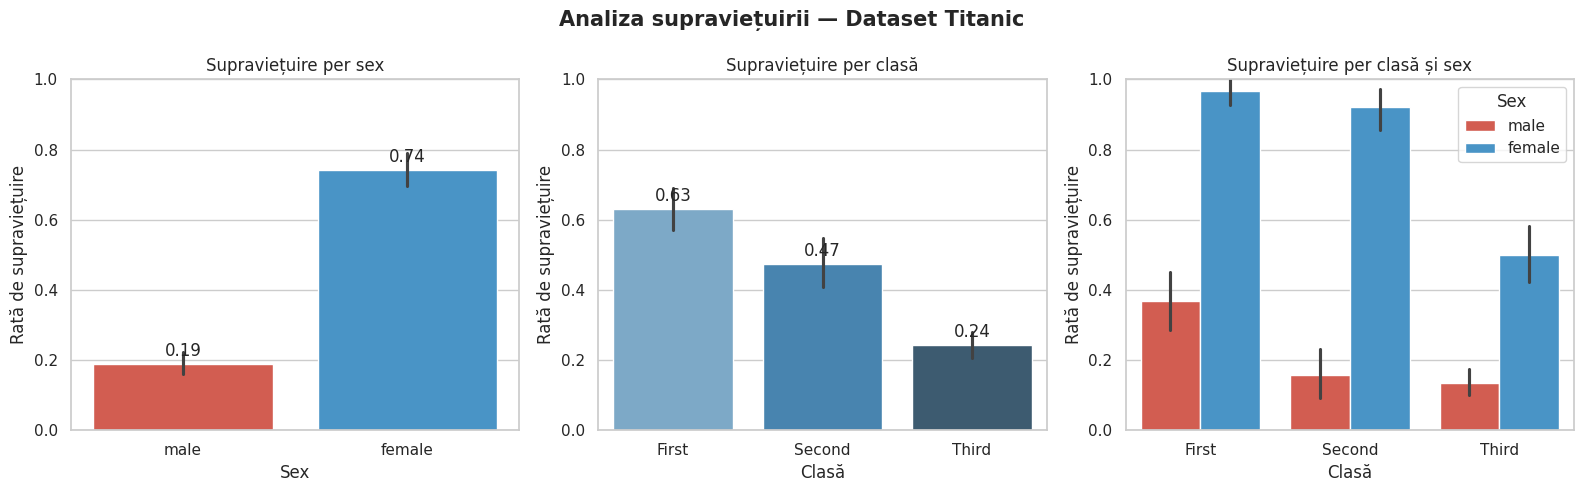

In [ ]:
# Creăm figura cu 3 subplot-uri
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analiza supraviețuirii — Dataset Titanic', fontsize=15, fontweight='bold')

# Subplot 1: Rata de supraviețuire per sex
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', ax=axes[0],
            errorbar='ci', palette=['#e74c3c', '#3498db'], legend=False)
axes[0].set_title('Supraviețuire per sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Rată de supraviețuire')
axes[0].set_ylim(0, 1)
# Adăugăm valorile pe bare
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3)

# Subplot 2: Rata de supraviețuire per clasă
sns.barplot(data=titanic, x='class', y='survived', hue='class', ax=axes[1],
            errorbar='ci', order=['First', 'Second', 'Third'],
            palette='Blues_d', legend=False)
axes[1].set_title('Supraviețuire per clasă')
axes[1].set_xlabel('Clasă')
axes[1].set_ylabel('Rată de supraviețuire')
axes[1].set_ylim(0, 1)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3)

# Subplot 3: Rata per sex și clasă
sns.barplot(data=titanic, x='class', y='survived', hue='sex',
            ax=axes[2], errorbar='ci',
            order=['First', 'Second', 'Third'],
            palette=['#e74c3c', '#3498db'])
axes[2].set_title('Supraviețuire per clasă și sex')
axes[2].set_xlabel('Clasă')
axes[2].set_ylabel('Rată de supraviețuire')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig('titanic_analiza.png', dpi=150, bbox_inches='tight')
plt.show()

## Concluzii și observații

Din analiza făcută, putem trage următoarele concluzii:

In [ ]:
# Afișăm concluziile statistice
print("=== Concluzii și observații cheie ===")
print(f"• Femei supraviețuitoare: {rata_sex.loc['female', 'Rată supraviețuire']:.1%} "
      f"({int(rata_sex.loc['female', 'Număr pasageri'])} pasageri)")
print(f"• Bărbați supraviețuitori: {rata_sex.loc['male', 'Rată supraviețuire']:.1%} "
      f"({int(rata_sex.loc['male', 'Număr pasageri'])} pasageri)")
print(f"• Diferență dramatică: +{rata_sex.loc['female', 'Rată supraviețuire'] - rata_sex.loc['male', 'Rată supraviețuire']:.1%} "
      f"pentru femei")
print(f"• Pasagerii clasa I au supraviețuit în proporție de {rata_clasa.loc['First', 'Rată supraviețuire']:.1%}, "
      f"comparativ cu doar {rata_clasa.loc['Third', 'Rată supraviețuire']:.1%} în clasa III")

print("\nConcluzie finală: Femeile și pasagerii din clasa I au avut rate de supraviețuire semnificativ mai mari,")
print("reflectând atât politica 'femei și copii primii', cât și privilegiile de clasă socială.")
print("\nObservație: Bărbații din clasa a III-a au avut cele mai mici șanse de supraviețuire, în timp ce")
print("femeile din clasa I au supraviețuit aproape toate. Acest lucru arată inegalitățile sociale din acea vreme.")

=== Concluzii și observații cheie ===
• Femei supraviețuitoare: 74.2% (314 pasageri)
• Bărbați supraviețuitori: 18.9% (577 pasageri)
• Diferență dramatică: +55.3% pentru femei
• Pasagerii clasa I au supraviețuit în proporție de 63.0%, comparativ cu doar 24.2% în clasa III

Concluzie finală: Femeile și pasagerii din clasa I au avut rate de supraviețuire semnificativ mai mari,
reflectând atât politica 'femei și copii primii', cât și privilegiile de clasă socială.

Observație: Bărbații din clasa a III-a au avut cele mai mici șanse de supraviețuire, în timp ce
femeile din clasa I au supraviețuit aproape toate. Acest lucru arată inegalitățile sociale din acea vreme.
